# Gaze Target Detection — step by step on still images

Work through the pipeline one stage at a time, on images, before running it live.
Each stage shows you exactly what the model produced, so you can see *why* it
decided what it decided.

**The 5 stages:**

| # | Stage | Question it answers |
|---|-------|--------------------|
| 1 | Head detection | Where is the person's head? |
| 2 | Gaze heatmap | Where in the image are they looking? |
| 3 | Target scoring | Which registered card did that land on? |
| 4 | Temporal filter | Have they looked long enough to mean it? |
| 5 | Emit | Say the label |

**Setup first** (from the repo root):
```bash
pip install -r requirements.txt
pip install jupyter matplotlib
./scripts/download_models.sh
python scripts/fetch_testdata.py
```

In [1]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
MODELS = ROOT / "models"

from gaze_target import GazelleONNX, HeadDetector, Target, TargetSet
from gaze_target import GazeStateFilter, TemporalConfig, NONE_LABEL

plt.rcParams["figure.figsize"] = (11, 6)

def show(img_bgr, title="", ax=None):
    """OpenCV uses BGR, matplotlib expects RGB."""
    ax = ax or plt.gca()
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
    return ax

print("ready")

ready


sh: line 1: hostname: command not found


## Load an image

We use a photo where we know the answer: the woman is looking at the phone in her
raised hand. Ground truth matters — otherwise you cannot tell a working model from
a lucky one.

We resize to 640x480 because that is a realistic webcam resolution.

frame: 640x480


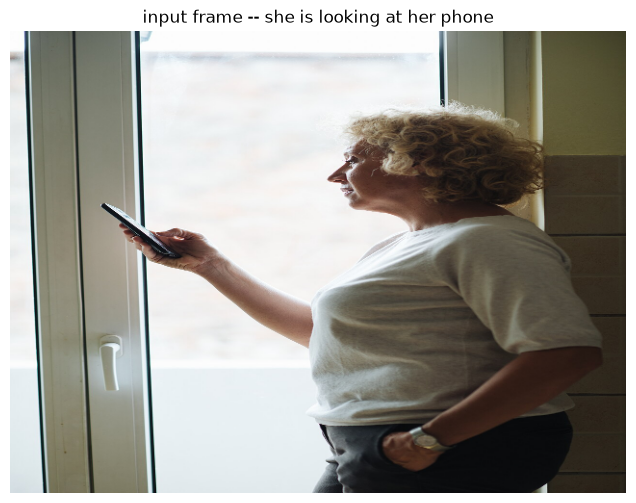

In [2]:
IMAGE = ROOT / "testdata" / "phone_woman.jpg"
frame = cv2.imread(str(IMAGE))
assert frame is not None, f"missing {IMAGE} -- run: python scripts/fetch_testdata.py"

frame = cv2.resize(frame, (640, 480))
H, W = frame.shape[:2]
print(f"frame: {W}x{H}")
show(frame, "input frame -- she is looking at her phone")
plt.show()

## Stage 1 — Head detection

**Model:** DEIMv2 HGNetV2-Pico Wholebody34, 6 MB ONNX.

It detects 34 body parts; we keep only **class 7 = head**.

Why we need it: the gaze model must be told *whose* gaze to predict. In a frame
with a patient and a nurse, the head box is what selects the person.

`primary_head()` picks the **largest** head, not the highest-scoring one — the
patient is closest to the camera so appears biggest, while a visitor further back
appears smaller.

heads found: 1
  box=(321, 71, 562, 207)  score=0.879  area=32776px

chosen (largest): (321, 71, 562, 207)


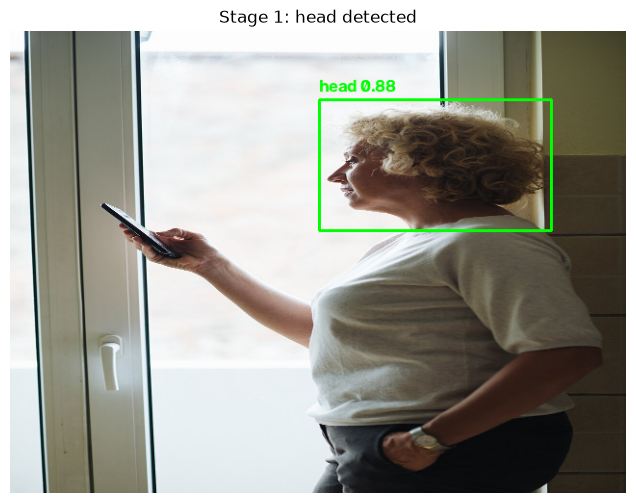

In [3]:
detector = HeadDetector(MODELS / "deimv2_head.onnx")

all_heads = detector(frame)
head = detector.primary_head(frame)

print(f"heads found: {len(all_heads)}")
for d in all_heads:
    print(f"  box={d.box}  score={d.score:.3f}  area={d.area}px")
print(f"\nchosen (largest): {head.box}")

vis = frame.copy()
x1, y1, x2, y2 = head.box
cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
cv2.putText(vis, f"head {head.score:.2f}", (x1, y1 - 8),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
show(vis, "Stage 1: head detected")
plt.show()

## Stage 2 — Gaze heatmap

**Model:** distilled Gaze-LLE ([CVPR 2025](https://arxiv.org/abs/2412.09586)).

This is the core of the system. It takes the **whole image** plus the head box, and
returns two things:

- `heatmap` — a **64x64** grid, values 0..1. High value = likely gaze location.
- `inout` — 0..1, how likely the gaze target is inside the frame at all.

Note it looks at the *whole scene*, not just the eyes. That is what lets it use
context: it knows a phone is a plausible thing to look at.

We start with **Atto** (2.93M params, 320x320 input) because benchmarking showed it
is by far the fastest on CPU while still localising correctly.

In [4]:
gaze_model = GazelleONNX(
    MODELS / "gazelle_hgnetv2_atto_inout_distill_1x3x320x320_1xNx4.onnx"
)
print(f"model input size: {gaze_model.in_w}x{gaze_model.in_h}")

result = gaze_model(frame, [head.box])[0]

print(f"\nraw heatmap shape : {result.raw_heatmap.shape}   <-- always 64x64")
print(f"resized to frame  : {result.heatmap.shape}")
print(f"in-frame score    : {result.inout:.3f}")
print(f"heatmap peak      : {result.peak_xy}  (brightest pixel)")

model input size: 320x320

raw heatmap shape : (32, 32)   <-- always 64x64
resized to frame  : (480, 640)
in-frame score    : 0.956
heatmap peak      : (150, 217)  (brightest pixel)


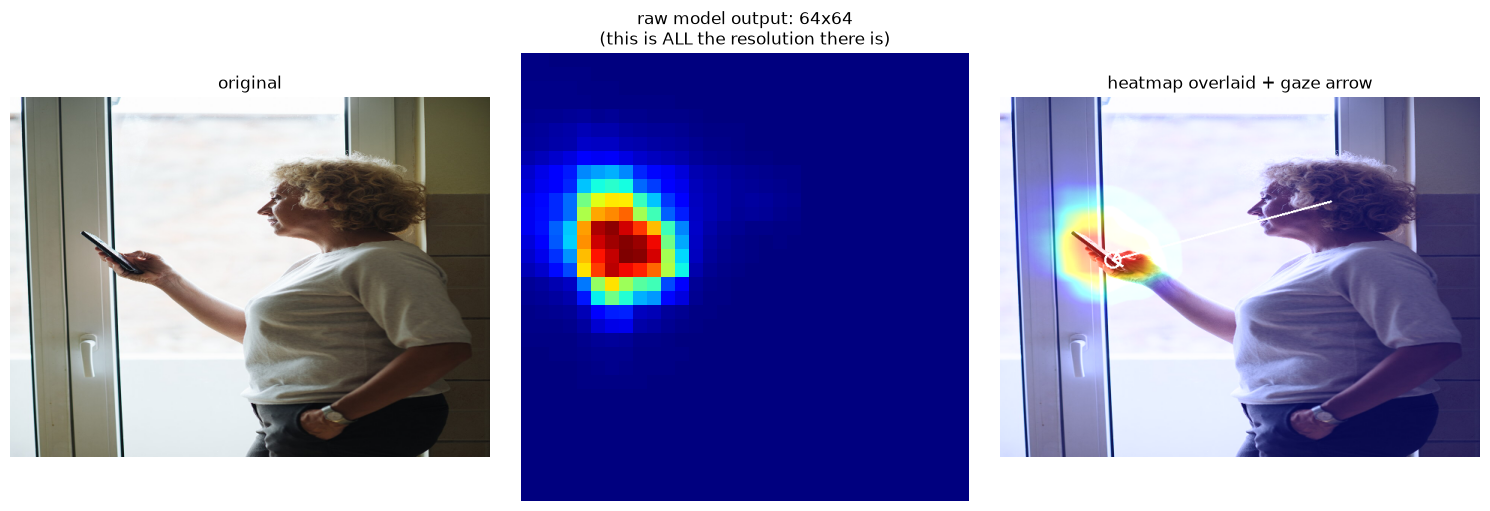

The hot spot should sit on the phone in her raised hand.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

show(frame, "original", axes[0])

axes[1].imshow(result.raw_heatmap, cmap="jet")
axes[1].set_title("raw model output: 64x64\n(this is ALL the resolution there is)")
axes[1].axis("off")

hm8 = np.clip(result.heatmap * 255, 0, 255).astype(np.uint8)
overlay = cv2.addWeighted(frame, 1.0, cv2.applyColorMap(hm8, cv2.COLORMAP_JET), 0.5, 0)
hx, hy = (head.box[0] + head.box[2]) // 2, (head.box[1] + head.box[3]) // 2
cv2.arrowedLine(overlay, (hx, hy), result.peak_xy, (255, 255, 255), 2, tipLength=0.05)
cv2.circle(overlay, result.peak_xy, 10, (255, 255, 255), 2)
show(overlay, "heatmap overlaid + gaze arrow", axes[2])

plt.tight_layout()
plt.show()
print("The hot spot should sit on the phone in her raised hand.")

### Why 64x64 matters — the resolution ceiling

The middle plot above is the model's **entire** spatial output. Everything else is
just interpolation. So:

- at 640x480, one heatmap cell covers **10 x 7.5 pixels**
- a small object (say a medicine strip at 30x15 px) spans only ~4x2 cells
- two such objects side by side **cannot be told apart**

This is a property of the model, not of its training. It is the single biggest
constraint on how you lay out the cards — and it is why bigger cards, spread
further apart, beats any model upgrade.

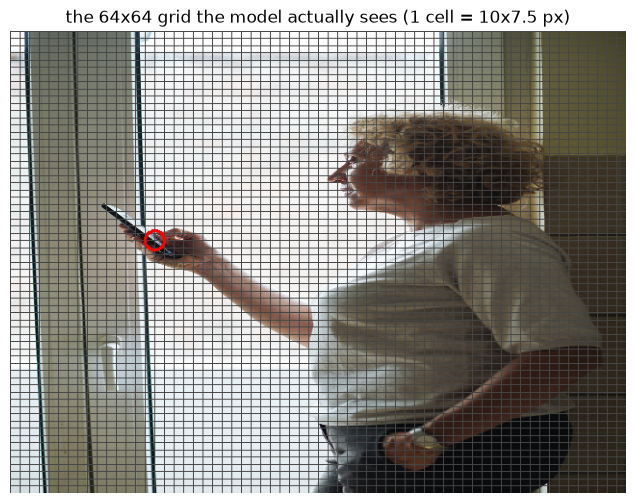

In [6]:
vis = frame.copy()
cell_w, cell_h = W / 64, H / 64
for i in range(65):
    cv2.line(vis, (int(i * cell_w), 0), (int(i * cell_w), H), (70, 70, 70), 1)
    cv2.line(vis, (0, int(i * cell_h)), (W, int(i * cell_h)), (70, 70, 70), 1)
cv2.circle(vis, result.peak_xy, 10, (0, 0, 255), 2)
show(vis, f"the 64x64 grid the model actually sees (1 cell = {cell_w:.0f}x{cell_h:.1f} px)")
plt.show()

## Stage 3 — Target scoring

The heatmap is a picture; we need a **label**. So we register boxes for each
communication target and ask how much heatmap mass fell inside each one.

The maths:

```
P(target_i) = inout x (mass inside box i / mass over whole frame)
P(NONE)     = 1 - sum of all P(target_i)
```

Here `PHONE` is the true target and the other three are **decoys** placed like a
bedside board — they should score near zero.

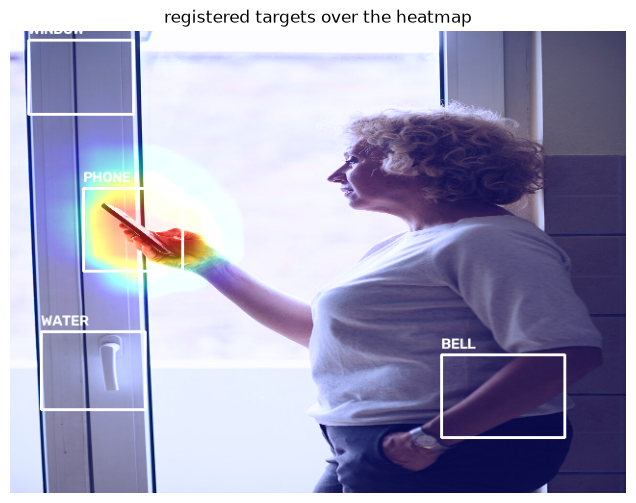

In [7]:
LAYOUT = {                              # normalized (x1, y1, x2, y2)
    "PHONE":  (0.12, 0.34, 0.28, 0.52),  # her hand -- the TRUE target
    "WINDOW": (0.03, 0.02, 0.20, 0.18),  # decoy
    "WATER":  (0.05, 0.65, 0.22, 0.82),  # decoy
    "BELL":   (0.70, 0.70, 0.90, 0.88),  # decoy
}

target_set = TargetSet(
    targets=[
        Target(label=k, box=(int(a * W), int(b * H), int(c * W), int(d * H)))
        for k, (a, b, c, d) in LAYOUT.items()
    ],
    frame_size=(W, H),
)

vis = cv2.addWeighted(frame, 1.0, cv2.applyColorMap(hm8, cv2.COLORMAP_JET), 0.45, 0)
for t in target_set.targets:
    a, b, c, d = t.box
    cv2.rectangle(vis, (a, b), (c, d), (255, 255, 255), 2)
    cv2.putText(vis, t.label, (a, b - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                (255, 255, 255), 2)
show(vis, "registered targets over the heatmap")
plt.show()

inout = 0.956

target            P      mass  peak inside?
PHONE         0.589     0.616  YES
WINDOW        0.013     0.014  no
WATER         0.006     0.006  no
BELL          0.000     0.000  no
NONE          0.392

sum = 1.000  (a proper probability distribution)

winner: PHONE   (ground truth: PHONE)


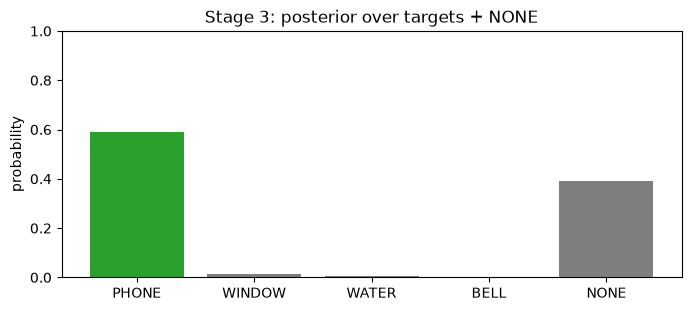

In [8]:
posterior = target_set.score(result.heatmap, result.inout, result.peak_xy)

print(f"inout = {result.inout:.3f}\n")
print(f"{'target':<10} {'P':>8}  {'mass':>8}  peak inside?")
for d in target_set.detail(result.heatmap, result.inout, result.peak_xy):
    print(f"{d.label:<10} {d.probability:>8.3f}  {d.mass:>8.3f}  "
          f"{'YES' if d.peak_inside else 'no'}")
print(f"{NONE_LABEL:<10} {posterior[NONE_LABEL]:>8.3f}")
print(f"\nsum = {sum(posterior.values()):.3f}  (a proper probability distribution)")

winner = max(posterior, key=posterior.get)
print(f"\nwinner: {winner}   (ground truth: PHONE)")

labels = list(posterior.keys())
vals = [posterior[k] for k in labels]
colors = ["tab:green" if k == winner else "tab:gray" for k in labels]
plt.figure(figsize=(8, 3.2))
plt.bar(labels, vals, color=colors)
plt.ylabel("probability")
plt.title("Stage 3: posterior over targets + NONE")
plt.ylim(0, 1)
plt.show()

## Layout feasibility check

Run this **before** trusting any prediction. If targets are too small or too close
together in the 64x64 grid, the layout is unresolvable and no better model fixes it.

- a target needs **>= 9 cells** to have a stable peak
- two targets need to be **>= 3 cells apart** to be separable

In [9]:
rep = target_set.resolution_report(W, H)
print(f"1 heatmap cell = {rep['heatmap_cell_px'][0]} x {rep['heatmap_cell_px'][1]} px\n")
print(f"{'target':<10} {'cells':>8}  reliable")
for t in rep["targets"]:
    print(f"{t['label']:<10} {t['cells_total']:>8}  {'yes' if t['reliable'] else 'TOO SMALL'}")
print(f"\n{'pair':<24} {'cells':>8}  separable")
for p in rep["pairs"]:
    print(f"{p['pair']:<24} {p['dist_cells']:>8}  {'yes' if p['separable'] else 'TOO CLOSE'}")
print(f"\nlayout_ok = {rep['layout_ok']}")
for w in rep["warnings"]:
    print(f"  WARNING: {w}")

1 heatmap cell = 10.0 x 7.5 px

target        cells  reliable
PHONE         118.1  yes
WINDOW        111.9  yes
WATER         116.6  yes
BELL          146.8  yes

pair                        cells  separable
PHONE <-> WATER             19.97  yes
PHONE <-> WINDOW            21.81  yes
WINDOW <-> WATER            40.69  yes
WATER <-> BELL              42.75  yes
PHONE <-> BELL              44.84  yes
WINDOW <-> BELL             62.26  yes

layout_ok = True


## Stage 4 — Temporal filter (why one frame is never enough)

If we emitted the argmax of every frame, every accidental glance would fire a
command. That is the **Midas touch problem**, and it makes gaze interfaces
unusable.

So a sticky HMM accumulates evidence over time. It starts in `NONE` — the system
must *earn* a selection. To fire, all three must hold for `dwell_frames` in a row:

1. belief >= `commit_threshold` (0.65)
2. margin over runner-up >= `margin_threshold` (0.20)
3. sustained, not instantaneous

Watch the `dwell` column climb, then fire.

In [10]:
filt = GazeStateFilter(
    labels=target_set.labels,
    config=TemporalConfig(dwell_frames=8, commit_threshold=0.65, margin_threshold=0.20),
)

history = []
print(f"{'frame':>5} {'top':<8} {'P':>7} {'margin':>7} {'dwell':>6}  emitted")

# frames 1-12: looking at the phone.  frames 13-20: looking at nothing.
for i in range(1, 21):
    if i <= 12:
        obs, io = posterior, result.inout
    else:
        obs, io = {NONE_LABEL: 1.0}, 0.0
    d = filt.update(obs, inout=io)
    history.append(dict(d.belief))
    flag = "  <-- looks away" if i == 13 else ""
    print(f"{i:>5} {d.top_label:<8} {d.top_prob:>7.3f} {d.margin:>7.3f} "
          f"{d.dwell_count:>6}  {d.emitted or ''}{flag}")

frame top            P  margin  dwell  emitted
    1 NONE       0.959   0.919      0  
    2 NONE       0.904   0.810      0  
    3 NONE       0.834   0.669      0  
    4 NONE       0.747   0.496      0  
    5 NONE       0.648   0.296      0  
    6 NONE       0.542   0.085      0  
    7 PHONE      0.560   0.122      0  
    8 PHONE      0.654   0.308      1  
    9 PHONE      0.732   0.465      2  
   10 PHONE      0.794   0.588      3  
   11 PHONE      0.840   0.681      4  
   12 PHONE      0.873   0.747      5  
   13 NONE       1.000   1.000      0    <-- looks away
   14 NONE       1.000   1.000      0  
   15 NONE       1.000   1.000      0  
   16 NONE       1.000   1.000      0  
   17 NONE       1.000   1.000      0  
   18 NONE       1.000   1.000      0  
   19 NONE       1.000   1.000      0  
   20 NONE       1.000   1.000      0  


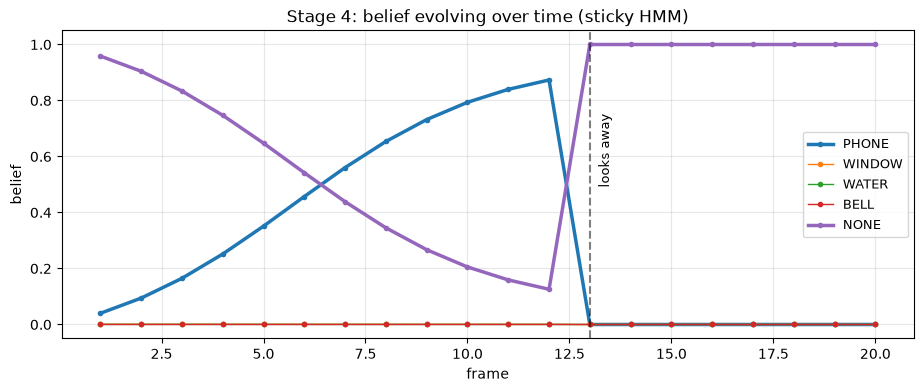

In [11]:
plt.figure(figsize=(11, 4))
for label in [*target_set.labels, NONE_LABEL]:
    series = [h.get(label, 0) for h in history]
    plt.plot(range(1, len(history) + 1), series, marker="o", ms=3, label=label,
             lw=2.5 if label in ("PHONE", NONE_LABEL) else 1)
plt.axvline(13, color="k", ls="--", alpha=0.5)
plt.text(13.2, 0.5, "looks away", rotation=90, fontsize=9)
plt.xlabel("frame")
plt.ylabel("belief")
plt.title("Stage 4: belief evolving over time (sticky HMM)")
plt.legend(loc="center right", fontsize=9)
plt.grid(alpha=0.3)
plt.show()

## Compare all the model variants

Same image, every variant. Note the pattern: **input resolution dominates CPU
latency, not parameter count.** Atto (2.93M @ 320px) and Pico (3.51M @ 640px) have
similar sizes but very different speeds.

In [12]:
import time

VARIANTS = [
    ("Atto",  "gazelle_hgnetv2_atto_inout_distill_1x3x320x320_1xNx4.onnx", 2.93),
    ("Femto", "gazelle_hgnetv2_femto_inout_distill_1x3x416x416_1xNx4.onnx", 3.15),
    ("Pico",  "gazelle_hgnetv2_pico_inout_distill_1x3x640x640_1xNx4.onnx", 3.51),
    ("S",     "gazelle_dinov3_vit_tiny_inout_1x3x640x640_1xNx4.onnx", 8.17),
    ("X",     "gazelle_dinov3_vits16plus_inout_1x3x640x640_1xNx4.onnx", 31.43),
]

rows, peaks = [], {}
for name, fname, params in VARIANTS:
    path = MODELS / fname
    if not path.is_file():
        print(f"{name}: missing (run ./scripts/download_models.sh --all)")
        continue
    m = GazelleONNX(path)
    m(frame, [head.box])                              # warm up
    t0 = time.perf_counter()
    for _ in range(5):
        r = m(frame, [head.box])[0]
    ms = (time.perf_counter() - t0) / 5 * 1000
    p = target_set.score(r.heatmap, r.inout, r.peak_xy)
    rows.append((name, params, m.in_w, ms, 1000 / ms, r.inout, p["PHONE"]))
    peaks[name] = r.peak_xy

print(f"{'variant':<8} {'params':>8} {'input':>6} {'ms':>8} {'FPS':>7} "
      f"{'inout':>7} {'P(PHONE)':>9}")
for n, pr, iw, ms, fps, io, pp in rows:
    print(f"{n:<8} {pr:>7.2f}M {iw:>6} {ms:>8.1f} {fps:>7.1f} {io:>7.3f} {pp:>9.3f}")
print("\npeak location per variant (they should cluster on the phone):")
for n, xy in peaks.items():
    print(f"  {n:<8} {xy}")

variant    params  input       ms     FPS   inout  P(PHONE)
Atto        2.93M    320     19.6    51.0   0.956     0.589
Femto       3.15M    416     26.3    38.0   0.979     0.723
Pico        3.51M    640    127.8     7.8   0.999     0.879
S           8.17M    640    264.0     3.8   0.952     0.807
X          31.43M    640    834.8     1.2   0.691     0.613

peak location per variant (they should cluster on the phone):
  Atto     (150, 217)
  Femto    (113, 195)
  Pico     (135, 213)
  S        (114, 184)
  X        (125, 198)


## Try your own image

Take a photo of yourself looking at an object, drop it in `testdata/`, and run this.
This is the quickest way to build intuition before going live.

Change `MY_IMAGE` below.

head (276, 21, 497, 228) score=0.853
inout=0.022  peak=(49, 97)


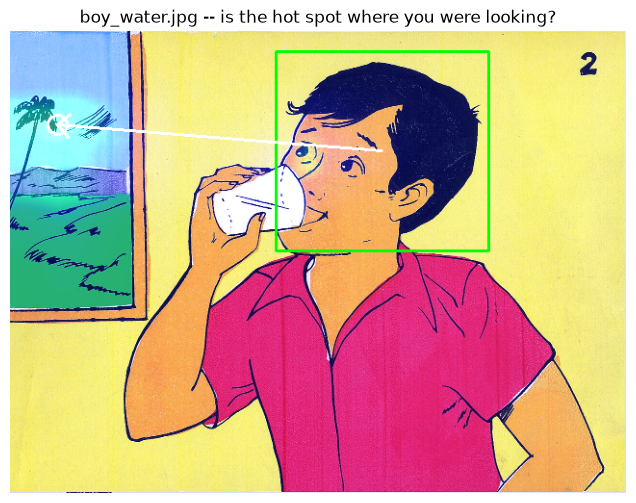

In [13]:
MY_IMAGE = ROOT / "testdata" / "boy_water.jpg"   # <-- change me

img = cv2.imread(str(MY_IMAGE))
if img is None:
    print(f"not found: {MY_IMAGE}")
else:
    img = cv2.resize(img, (640, 480))
    h2 = detector.primary_head(img)
    if h2 is None:
        print("No head detected. Move closer to the camera or improve lighting.")
    else:
        r2 = gaze_model(img, [h2.box])[0]
        print(f"head {h2.box} score={h2.score:.3f}")
        print(f"inout={r2.inout:.3f}  peak={r2.peak_xy}")
        hm = np.clip(r2.heatmap * 255, 0, 255).astype(np.uint8)
        v = cv2.addWeighted(img, 1.0, cv2.applyColorMap(hm, cv2.COLORMAP_JET), 0.5, 0)
        a, b, c, d = h2.box
        cv2.rectangle(v, (a, b), (c, d), (0, 255, 0), 2)
        cv2.arrowedLine(v, ((a + c) // 2, (b + d) // 2), r2.peak_xy,
                        (255, 255, 255), 2, tipLength=0.05)
        cv2.circle(v, r2.peak_xy, 10, (255, 255, 255), 2)
        show(v, f"{MY_IMAGE.name} -- is the hot spot where you were looking?")
        plt.show()

## What next

Once the heatmap lands where you expect on your own photos:

```bash
# register your real card layout (and read the feasibility warnings!)
python scripts/register_targets.py --camera 0 --out config/targets.json

# run live
python scripts/run_live.py --targets config/targets.json --camera 0 \
    --model atto
```

**Known limitation of this approach.** The heatmap is 2D, so two targets at
different distances from the camera but similar image positions cannot be
separated. That is structural, not a training problem, and it is why this
(Option 3) is the zero-calibration starting point rather than the final design.
See `docs/research-review.md`.